In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.10.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
PROJECT_ROOT = Path("..").resolve()
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

train_path = SPLIT_DIR / "state_farm_train_subject.csv"
val_path = SPLIT_DIR / "state_farm_val_subject.csv"
test_path = SPLIT_DIR / "state_farm_test_subject.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_df.head())

Train: (15899, 6)
Validation: (3439, 6)
Test: (3086, 6)


,subject,classname,img,filepath,file_exists,label
0,p014,c0,img_72495.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
1,p014,c0,img_62101.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
2,p014,c0,img_34774.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
3,p014,c0,img_100312.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
4,p014,c0,img_12279.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0


In [3]:
CLASS_ORDER = [f"c{i}" for i in range(10)]

CLASS_NAMES = {
    "c0": "safe driving",
    "c1": "texting right",
    "c2": "talking on the phone right",
    "c3": "texting left",
    "c4": "talking on the phone left",
    "c5": "operating the radio",
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger",
}

TARGET_NAMES = [f"{class_id} - {CLASS_NAMES[class_id]}" for class_id in CLASS_ORDER]

LABEL_MAP = {class_name: index for index, class_name in enumerate(CLASS_ORDER)}

print(LABEL_MAP)

{'c0': 0, 'c1': 1, 'c2': 2, 'c3': 3, 'c4': 4, 'c5': 5, 'c6': 6, 'c7': 7, 'c8': 8, 'c9': 9}


In [4]:
for split_name, split_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    print(split_name)
    print("Rows:", len(split_df))
    print("Missing paths:", split_df["filepath"].isna().sum())
    print("Missing labels:", split_df["label"].isna().sum())
    print("First image exists:", Path(split_df["filepath"].iloc[0]).exists())
    print()

train
Rows: 15899
Missing paths: 0
Missing labels: 0
First image exists: True

validation
Rows: 3439
Missing paths: 0
Missing labels: 0
First image exists: True

test
Rows: 3086
Missing paths: 0
Missing labels: 0
First image exists: True



In [14]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20

AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

In [6]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print("Datasets created successfully.")

Datasets created successfully.


In [7]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels.numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels: [3 2 0 3 2 0 0 4 3 2 4 1 8 2 5 8]


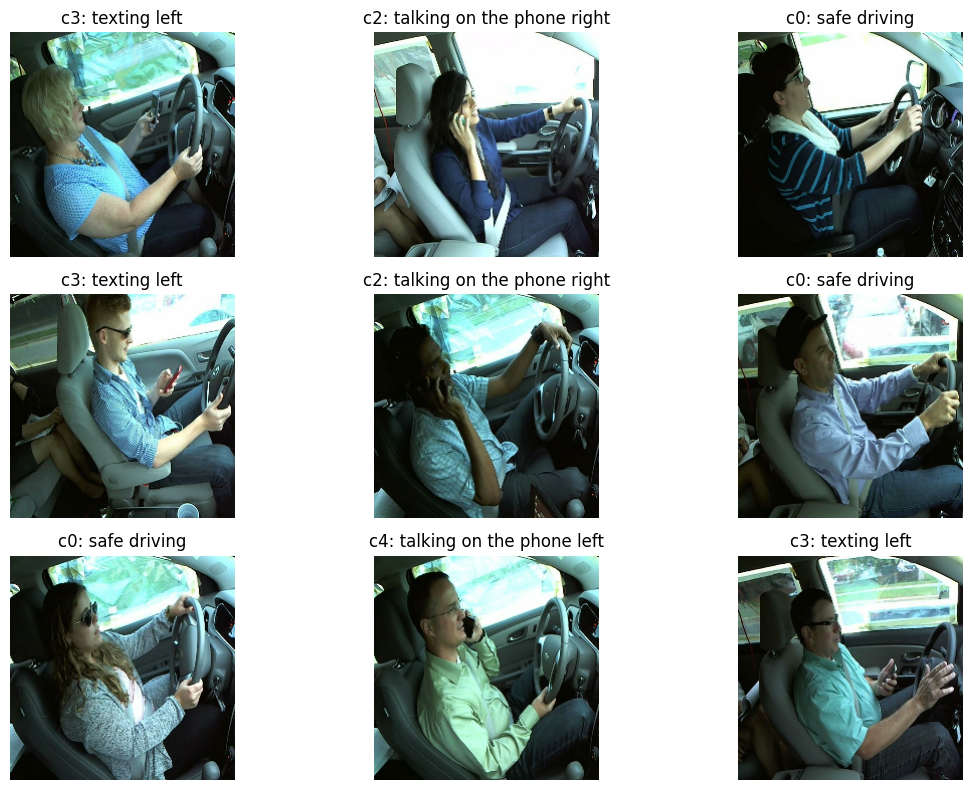

In [8]:
plt.figure(figsize=(12, 8))

for i in range(min(9, images.shape[0])):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    class_id = CLASS_ORDER[int(labels[i])]
    plt.title(f"{class_id}: {CLASS_NAMES[class_id]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.15),
], name="safe_augmentation")


def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    # Normalize pixel values from 0-255 to 0-1
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="baseline_cnn")
    return model


model = build_baseline_cnn(input_shape=IMG_SIZE + (3,), num_classes=10)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "baseline_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 safe_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_4 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 112, 112, 32)    

In [16]:
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "01_baseline_cnn"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
CM_DIR = RESULTS_DIR / "confusion_matrices"

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(EXPERIMENT_DIR / "best_baseline_cnn.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Experiment folder:", EXPERIMENT_DIR)

Experiment folder: D:\MSC_PROJECT\experiments\01_baseline_cnn


In [17]:
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

training_time_seconds = time.time() - start_time

print("Training time seconds:", training_time_seconds)
print("Training time minutes:", training_time_seconds / 60)

Epoch 1/20
994/994 [==============================] - ETA: 0s - loss: 1.6304 - accuracy: 0.4027
Epoch 1: val_accuracy improved from -inf to 0.26316, saving model to D:\MSC_PROJECT\experiments\01_baseline_cnn\best_baseline_cnn.keras
994/994 [==============================] - 128s 125ms/step - loss: 1.6304 - accuracy: 0.4027 - val_loss: 2.4877 - val_accuracy: 0.2632 - lr: 0.0010
Epoch 2/20
994/994 [==============================] - ETA: 0s - loss: 0.4596 - accuracy: 0.8502
Epoch 2: val_accuracy improved from 0.26316 to 0.40331, saving model to D:\MSC_PROJECT\experiments\01_baseline_cnn\best_baseline_cnn.keras
994/994 [==============================] - 116s 117ms/step - loss: 0.4596 - accuracy: 0.8502 - val_loss: 3.2447 - val_accuracy: 0.4033 - lr: 0.0010
Epoch 3/20
994/994 [==============================] - ETA: 0s - loss: 0.2386 - accuracy: 0.9254
Epoch 3: val_accuracy did not improve from 0.40331

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
994/994 [====

,loss,accuracy,val_loss,val_accuracy,lr
0,1.568620,0.427385,3.672810,0.235824,0.001
1,0.445887,0.854582,3.294805,0.389067,0.001


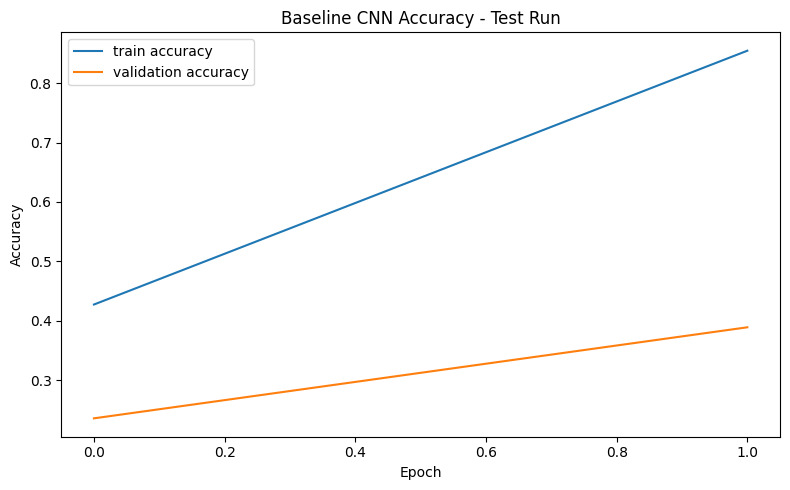

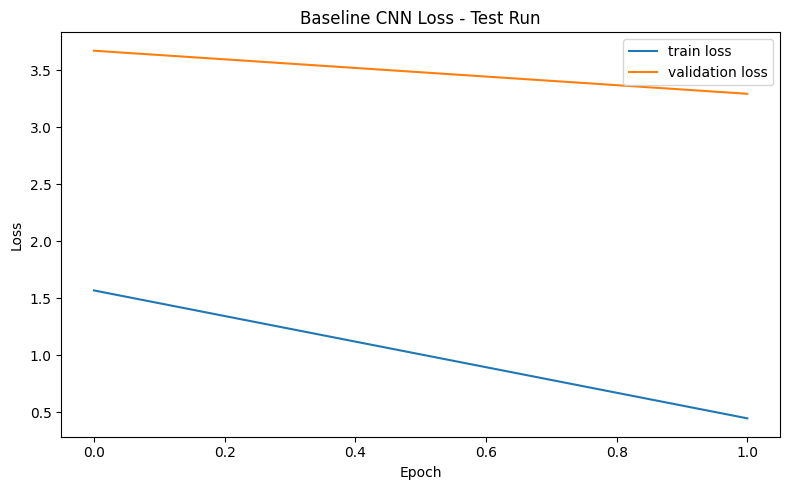

In [12]:
history_df = pd.DataFrame(history.history)

display(history_df)

history_df.to_csv(EXPERIMENT_DIR / "baseline_cnn_test_run_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="validation accuracy")
plt.title("Baseline CNN Accuracy - Test Run")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cnn_test_run_accuracy.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.title("Baseline CNN Loss - Test Run")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cnn_test_run_loss.png", dpi=300)
plt.show()

In [13]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation loss:", val_loss)
print("Validation accuracy:", val_accuracy)

215/215 [==============================] - 3s 12ms/step - loss: 3.2948 - accuracy: 0.3891
Validation loss: 3.294804811477661
Validation accuracy: 0.38906657695770264


In [18]:
best_model_path = EXPERIMENT_DIR / "best_baseline_cnn.keras"

best_model = tf.keras.models.load_model(best_model_path)

print("Loaded best model from:")
print(best_model_path)

Loaded best model from:
D:\MSC_PROJECT\experiments\01_baseline_cnn\best_baseline_cnn.keras


In [19]:
val_loss, val_accuracy = best_model.evaluate(val_ds)
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Best Baseline CNN Validation Loss:", val_loss)
print("Best Baseline CNN Validation Accuracy:", val_accuracy)

print("Best Baseline CNN Test Loss:", test_loss)
print("Best Baseline CNN Test Accuracy:", test_accuracy)

193/193 [==============================] - 5s 26ms/step - loss: 0.8917 - accuracy: 0.7560
Best Baseline CNN Validation Loss: 3.158165454864502
Best Baseline CNN Validation Accuracy: 0.6088979244232178
Best Baseline CNN Test Loss: 0.8916622996330261
Best Baseline CNN Test Accuracy: 0.7559947967529297


In [20]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

y_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

193/193 [==============================] - 3s 13ms/step
True labels shape: (3086,)
Predicted labels shape: (3086,)


In [21]:
report = classification_report(
    y_true,
    y_pred,
    target_names=TARGET_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_path = REPORTS_DIR / "baseline_cnn_classification_report.csv"
report_df.to_csv(report_path)

print("Saved classification report to:")
print(report_path)

,precision,recall,f1-score,support
c0 - safe driving,0.576087,0.670886,0.619883,316.000000
c1 - texting right,0.943662,0.618462,0.747212,325.000000
c2 - talking on the phone right,0.983444,0.878698,0.928125,338.000000
c3 - texting left,0.839142,0.972050,0.900719,322.000000
c4 - talking on the phone left,0.984277,0.907246,0.944193,345.000000
c5 - operating the radio,0.747222,0.822630,0.783115,327.000000
c6 - drinking,0.976654,0.807074,0.883803,311.000000
c7 - reaching behind,0.947368,0.552901,0.698276,293.000000
c8 - hair and makeup,0.521858,0.760956,0.619125,251.000000
c9 - talking to passenger,0.346369,0.480620,0.402597,258.000000


Saved classification report to:
D:\MSC_PROJECT\results\reports\baseline_cnn_classification_report.csv


In [22]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=TARGET_NAMES,
    columns=TARGET_NAMES
)

display(cm_df)

cm_csv_path = CM_DIR / "baseline_cnn_confusion_matrix.csv"
cm_df.to_csv(cm_csv_path)

print("Saved confusion matrix CSV to:")
print(cm_csv_path)

,c0 - safe driving,c1 - texting right,c2 - talking on the phone right,c3 - texting left,c4 - talking on the phone left,c5 - operating the radio,c6 - drinking,c7 - reaching behind,c8 - hair and makeup,c9 - talking to passenger
c0 - safe driving,212,10,0,27,0,10,0,0,7,50
c1 - texting right,49,201,0,1,0,1,3,0,68,2
c2 - talking on the phone right,0,0,297,0,0,0,1,5,13,22
c3 - texting left,2,0,0,313,0,0,0,1,2,4
c4 - talking on the phone left,0,0,2,21,313,1,0,1,4,3
c5 - operating the radio,3,0,1,0,0,269,1,0,0,53
c6 - drinking,0,0,0,0,0,0,251,0,18,42
c7 - reaching behind,0,2,2,11,0,4,0,162,62,50
c8 - hair and makeup,11,0,0,0,5,33,1,2,191,8
c9 - talking to passenger,91,0,0,0,0,42,0,0,1,124


Saved confusion matrix CSV to:
D:\MSC_PROJECT\results\confusion_matrices\baseline_cnn_confusion_matrix.csv


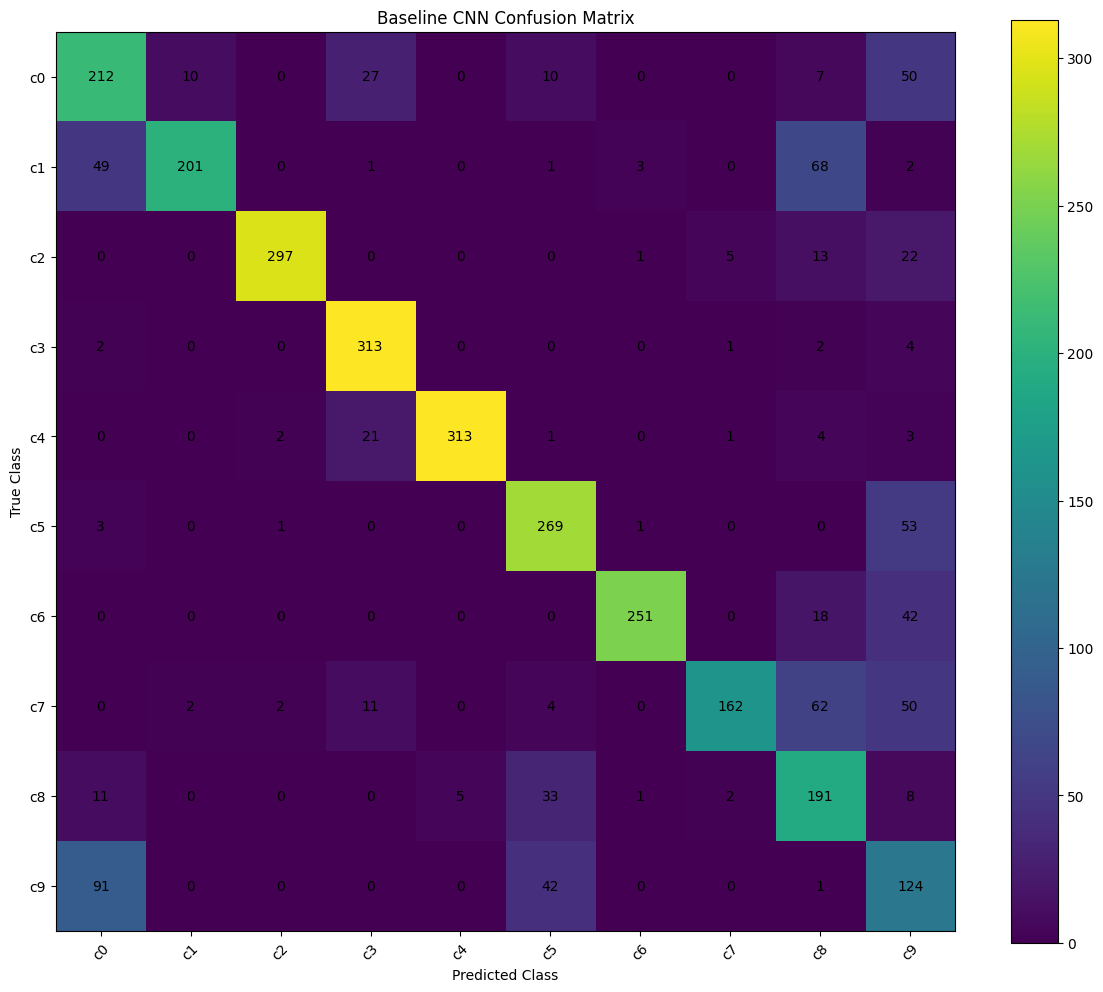

Saved confusion matrix image to:
D:\MSC_PROJECT\results\confusion_matrices\baseline_cnn_confusion_matrix.png


In [23]:
plt.figure(figsize=(12, 10))

plt.imshow(cm)
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(10), CLASS_ORDER, rotation=45)
plt.yticks(range(10), CLASS_ORDER)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_png_path = CM_DIR / "baseline_cnn_confusion_matrix.png"
plt.savefig(cm_png_path, dpi=300)
plt.show()

print("Saved confusion matrix image to:")
print(cm_png_path)

In [24]:
baseline_summary = {
    "model_name": "baseline_cnn",
    "image_size": str(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "best_validation_accuracy": float(max(history.history["val_accuracy"])),
    "final_test_accuracy": float(test_accuracy),
    "final_test_loss": float(test_loss),
    "training_time_minutes": training_time_seconds / 60,
    "model_path": str(best_model_path)
}

baseline_summary_df = pd.DataFrame([baseline_summary])

display(baseline_summary_df)

summary_path = REPORTS_DIR / "baseline_cnn_summary.csv"
baseline_summary_df.to_csv(summary_path, index=False)

print("Saved baseline summary to:")
print(summary_path)

,model_name,image_size,batch_size,epochs_requested,best_validation_accuracy,final_test_accuracy,final_test_loss,training_time_minutes,model_path
0,baseline_cnn,"(224, 224)",16,20,0.608898,0.755995,0.891662,11.867055,D:\MSC_PROJECT\experiments\01_baseline_cnn\bes...


Saved baseline summary to:
D:\MSC_PROJECT\results\reports\baseline_cnn_summary.csv
